In [60]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.radnav_stacked_pc_tb import RadnavStackedPCTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.plotter_localization import PlotterLocalization
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


In [61]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
TRAJ_FOLDER="/home/david/Documents/odometry/scripts/radnav_trajectories_09092024/gt_trajectories"

In [62]:
#setup the wilk dataset
folder_name = "CPSL_nav"
file_name = "cpsl_nav_1"
header_name = "cpsl"

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="cpsl_full.yaml"
)

plotter = PlotterLocalization(
    dataset=dataset,
    map_handler=map_handler
)

found 363 radar samples
found 363 lidar samples
found 363 camera samples
found 363 imu (orientation only) samples
found 363imu (full data) samples
found 363 vehicle velocity samples
loaded map from /data/radnav/maps/cpsl_full.yaml
loaded map free space from /data/radnav/maps/cpsl_full.yaml


average trajectory distance: 13.834795454215488
trajectory stdev: 0.41144318595092194


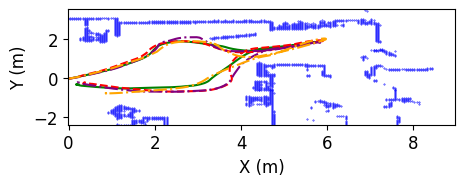

In [63]:
fig,ax = plt.subplots(figsize=(5,1.5))
colors = ["green","red","purple","orange"]
styles = ["-","--","-.","-."]
traj_distances = []

for i in range(4):
    file_name = "{}_nav_{}.npy".format(header_name,i+1)
    # history = np.load("/home/david/Documents/odometry/scripts/radnav_trajectories_09092024/est_trajectories/wilk_nav_1.npy")
    history = np.load("{}/{}".format(TRAJ_FOLDER,file_name))
    ax.plot(
        history[:,0],
        history[:,1],
        color=colors[i],
        linestyle=styles[i])
    
    dist = 0
    for j in range(len(history)-1):
        dist += np.linalg.norm(
            history[j+1] -\
            history[j]
        )
    traj_distances.append(dist)

print("average trajectory distance: {}".format(
    np.mean(np.array(traj_distances))
))
print("trajectory stdev: {}".format(
    np.std(np.array(traj_distances))
))

ax.set_xlim(
    np.min(history[:,0]) - 0,
    np.max(history[:,0]) + 3)
ax.set_ylim(
    np.min(history[:,1]) - 1.6,
    np.max(history[:,1]) + 1.5)
    
ax.set_title("Comparison of Navigation Trajectories",fontsize=plotter.font_size_title)
ax.set_xlabel("X (m)",fontsize=plotter.font_size_axis_labels)
ax.set_ylabel("Y (m)",fontsize=plotter.font_size_axis_labels)
ax.tick_params(labelsize=plotter.font_size_ticks)

#plot the map
ax.scatter(
    plotter.map_handler.map_points[:,0],
    plotter.map_handler.map_points[:,1],
    label="map",
    marker=".",
    s=0.5,
    color="blue")
#show the legend
# handles,labels = ax.get_legend_handles_labels()
# ax.legend(handles[:4],
#         labels[:4],
#         loc="upper right",
#         fontsize=plotter.font_size_legend)
ax.set_title("")
plt.show()
fig.savefig("Trajectories/navigation/{}.png".format(header_name))